In [1]:
import pandas as pd
import json
import re
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from collections import Counter
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (16, 5)
plt.rcParams['figure.dpi'] = 100

DATA_DIR = 'g4/'

def load_jsonl(filepath):
    records = []
    with open(filepath, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if line:
                records.append(json.loads(line))
    return pd.DataFrame(records)

cart_logs = load_jsonl(f'{DATA_DIR}logs/cart-service.log.jsonl')
order_logs = load_jsonl(f'{DATA_DIR}logs/order-service.log.jsonl')

cart_logs['timestamp'] = pd.to_datetime(cart_logs['timestamp'])
order_logs['timestamp'] = pd.to_datetime(order_logs['timestamp'])

print(f"Cart-service logs: {len(cart_logs)} lines")
print(f"Order-service logs: {len(order_logs)} lines")


Cart-service logs: 24094 lines
Order-service logs: 8045 lines


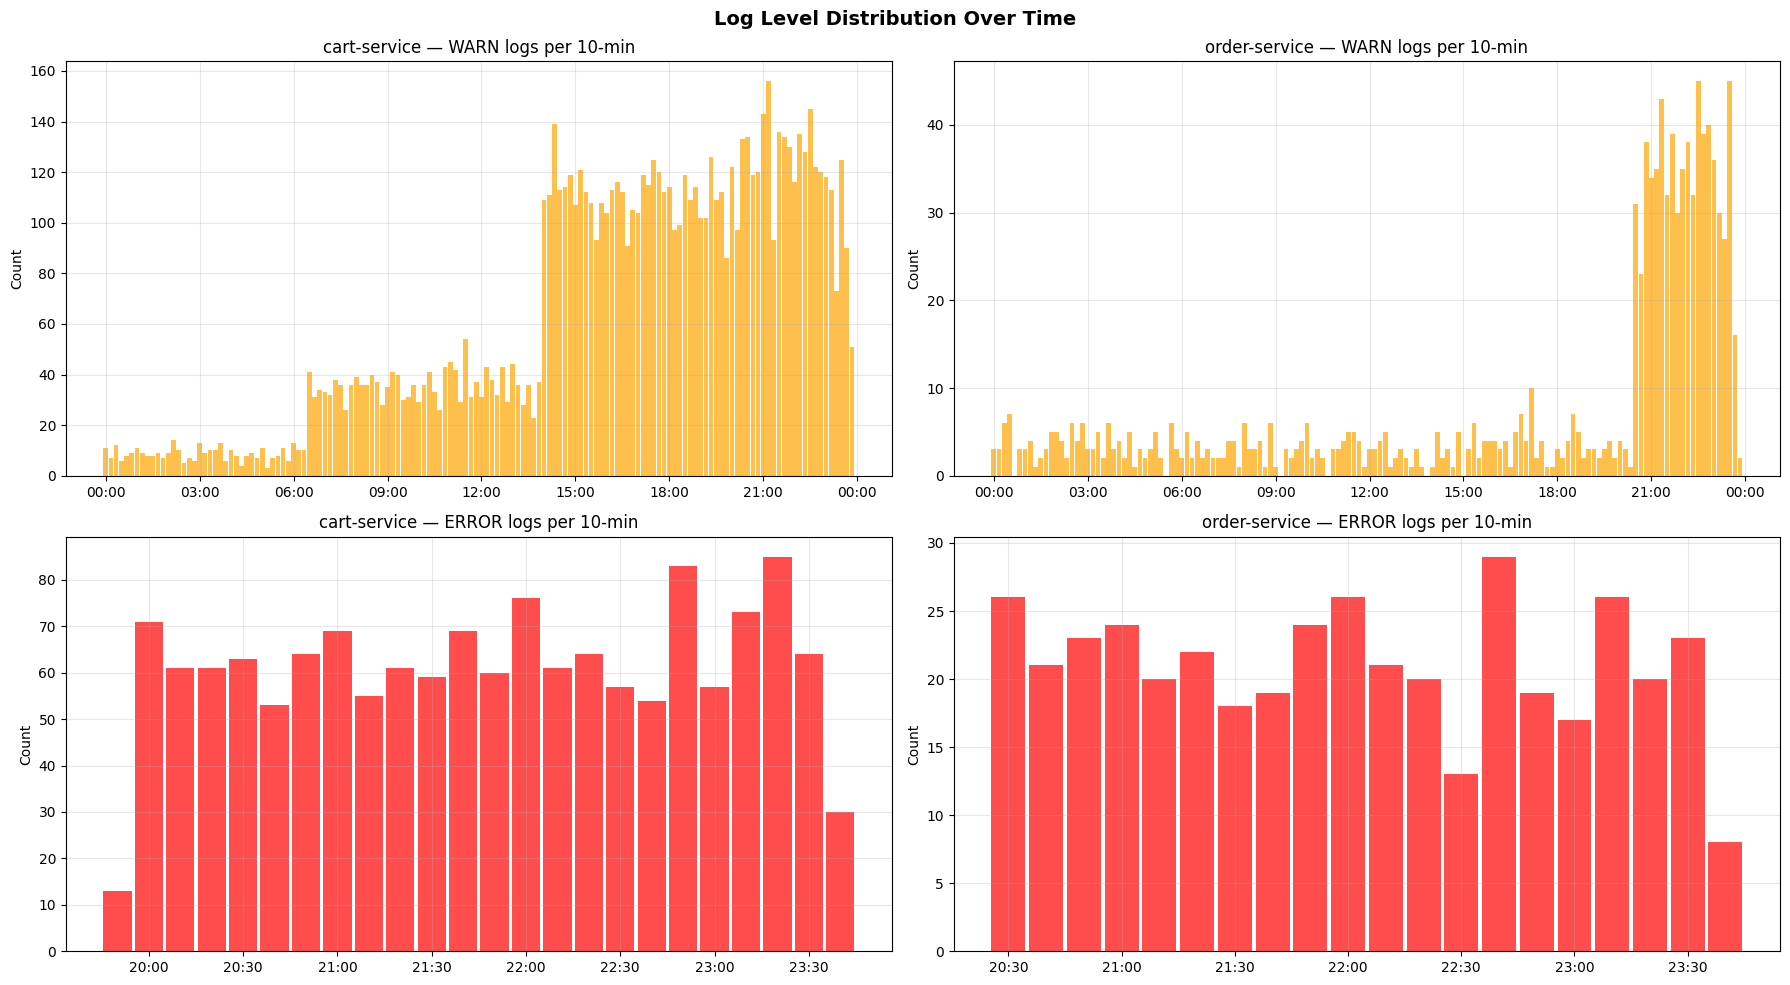

In [2]:
fig, axes = plt.subplots(2, 2, figsize=(18, 10))
fig.suptitle('Log Level Distribution Over Time', fontsize=14, fontweight='bold')

for idx, (name, logs) in enumerate([('cart-service', cart_logs), ('order-service', order_logs)]):
    # Log count per 10-min bucket by level
    logs_copy = logs.copy()
    logs_copy.set_index('timestamp', inplace=True)

    for level_idx, level in enumerate(['WARN', 'ERROR']):
        ax = axes[level_idx, idx]
        level_logs = logs_copy[logs_copy['level'] == level]
        if len(level_logs) > 0:
            counts = level_logs.resample('10min').size()
            ax.bar(counts.index, counts.values, width=pd.Timedelta('9min'), alpha=0.7,
                   color='orange' if level == 'WARN' else 'red')
        ax.set_title(f'{name} — {level} logs per 10-min')
        ax.set_ylabel('Count')
        ax.grid(True, alpha=0.3)
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))

plt.tight_layout()
plt.show()


In [3]:
def extract_template(message):
    """Extract a log template by replacing variable parts with placeholders."""
    template = message
    # Replace numbers
    template = re.sub(r'\b\d+\.\d+\b', '<FLOAT>', template)
    template = re.sub(r'\b\d+\b', '<NUM>', template)
    # Replace UUIDs/hex
    template = re.sub(r'[a-f0-9]{8,}', '<HEX>', template)
    # Replace orderId patterns
    template = re.sub(r'ORD-\S+', 'ORD-<ID>', template)
    # Replace userId patterns
    template = re.sub(r'userId=\S+', 'userId=<ID>', template)
    return template

# Apply to cart-service
cart_logs['template'] = cart_logs['message'].apply(extract_template)
order_logs['template'] = order_logs['message'].apply(extract_template)

print("=== Cart-Service Log Templates (Top 10) ===")
cart_template_counts = cart_logs['template'].value_counts()
for template, count in cart_template_counts.head(10).items():
    print(f"  [{count:5d}] {template}")


=== Cart-Service Log Templates (Top 10) ===
  [ 3194] Health check passed
  [ 3030] Item added to cart for userId=<ID>
  [ 2844] DB query executed table=cart rows=<NUM>
  [ 2675] ProductCatalogCache eviction failed: heap pressure too high
  [ 2037] Checkout completed orderId=ORD-<ID>
  [ 1841] ProductCatalogCache loaded <NUM> entries
  [ 1086] Connection pool nearing limit pool=db connections=<NUM>/<NUM>
  [  966] OutOfMemoryError imminent: available heap < <NUM>%
  [  819] Container OOMKilled: memory limit exceeded
  [  671] Cache warm-up slower than expected startup_ms=<NUM>


WARN/ERROR/FATAL logs to cluster: 11058


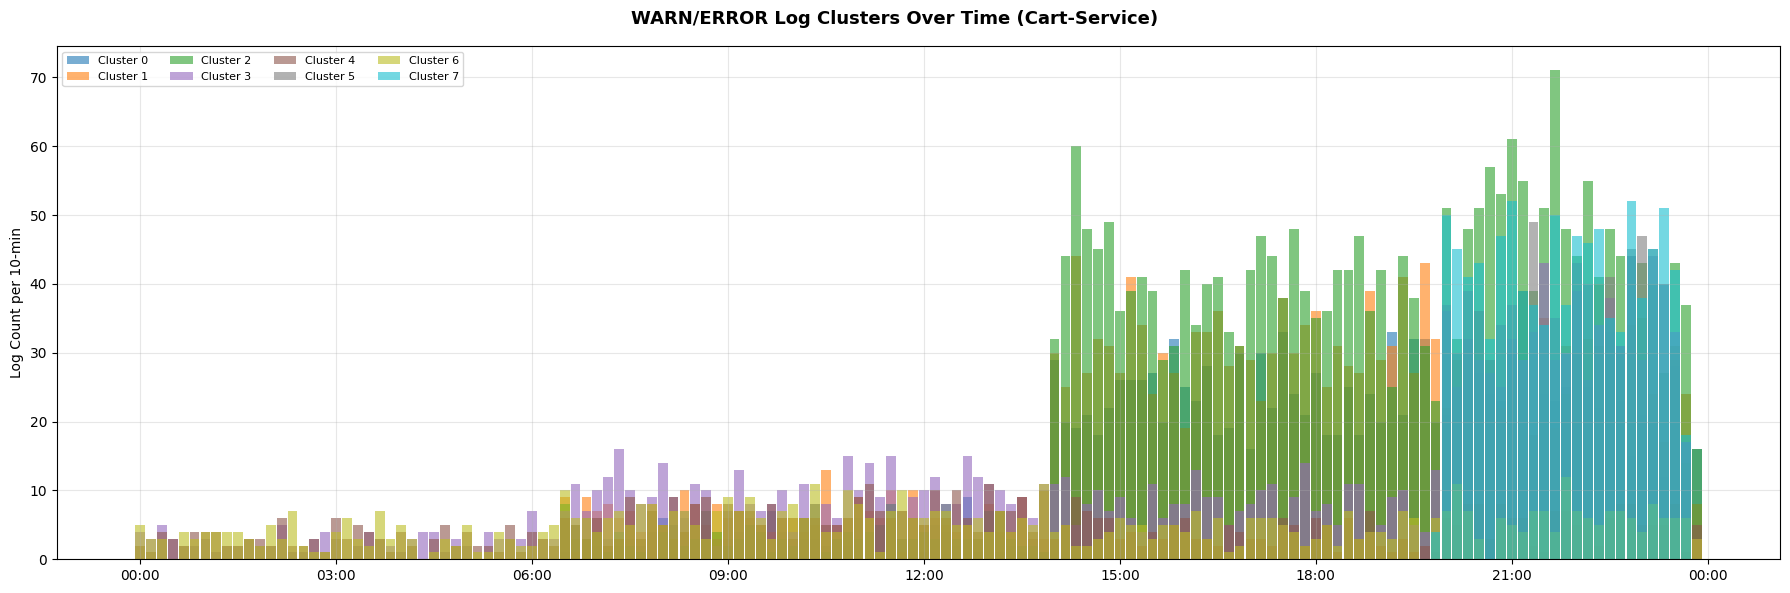

In [4]:
# Focus on WARN and ERROR logs for clustering (most interesting)
warn_error_logs = cart_logs[cart_logs['level'].isin(['WARN', 'ERROR', 'FATAL'])].copy()
print(f"WARN/ERROR/FATAL logs to cluster: {len(warn_error_logs)}")

if len(warn_error_logs) > 0:
    # TF-IDF vectorization
    vectorizer = TfidfVectorizer(max_features=200, stop_words='english', token_pattern=r'(?u)\b\w+\b')
    X_tfidf = vectorizer.fit_transform(warn_error_logs['message'])

    # Determine optimal k using inertia (elbow method)
    n_clusters = min(8, len(warn_error_logs))  # reasonable number of clusters

    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    warn_error_logs['cluster'] = kmeans.fit_predict(X_tfidf)

    # Plot cluster distribution over time
    fig, ax = plt.subplots(figsize=(18, 6))
    fig.suptitle('WARN/ERROR Log Clusters Over Time (Cart-Service)', fontsize=13, fontweight='bold')

    colors = plt.cm.tab10(np.linspace(0, 1, n_clusters))
    for cluster_id in range(n_clusters):
        cluster_logs_c = warn_error_logs[warn_error_logs['cluster'] == cluster_id]
        if len(cluster_logs_c) > 0:
            cluster_ts = cluster_logs_c.set_index('timestamp').resample('10min').size()
            ax.bar(cluster_ts.index, cluster_ts.values, width=pd.Timedelta('9min'),
                   alpha=0.6, color=colors[cluster_id], label=f'Cluster {cluster_id}')

    ax.set_ylabel('Log Count per 10-min')
    ax.legend(fontsize=8, ncol=4)
    ax.grid(True, alpha=0.3)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
    plt.tight_layout()
    plt.show()
else:
    print("No WARN/ERROR logs found.")


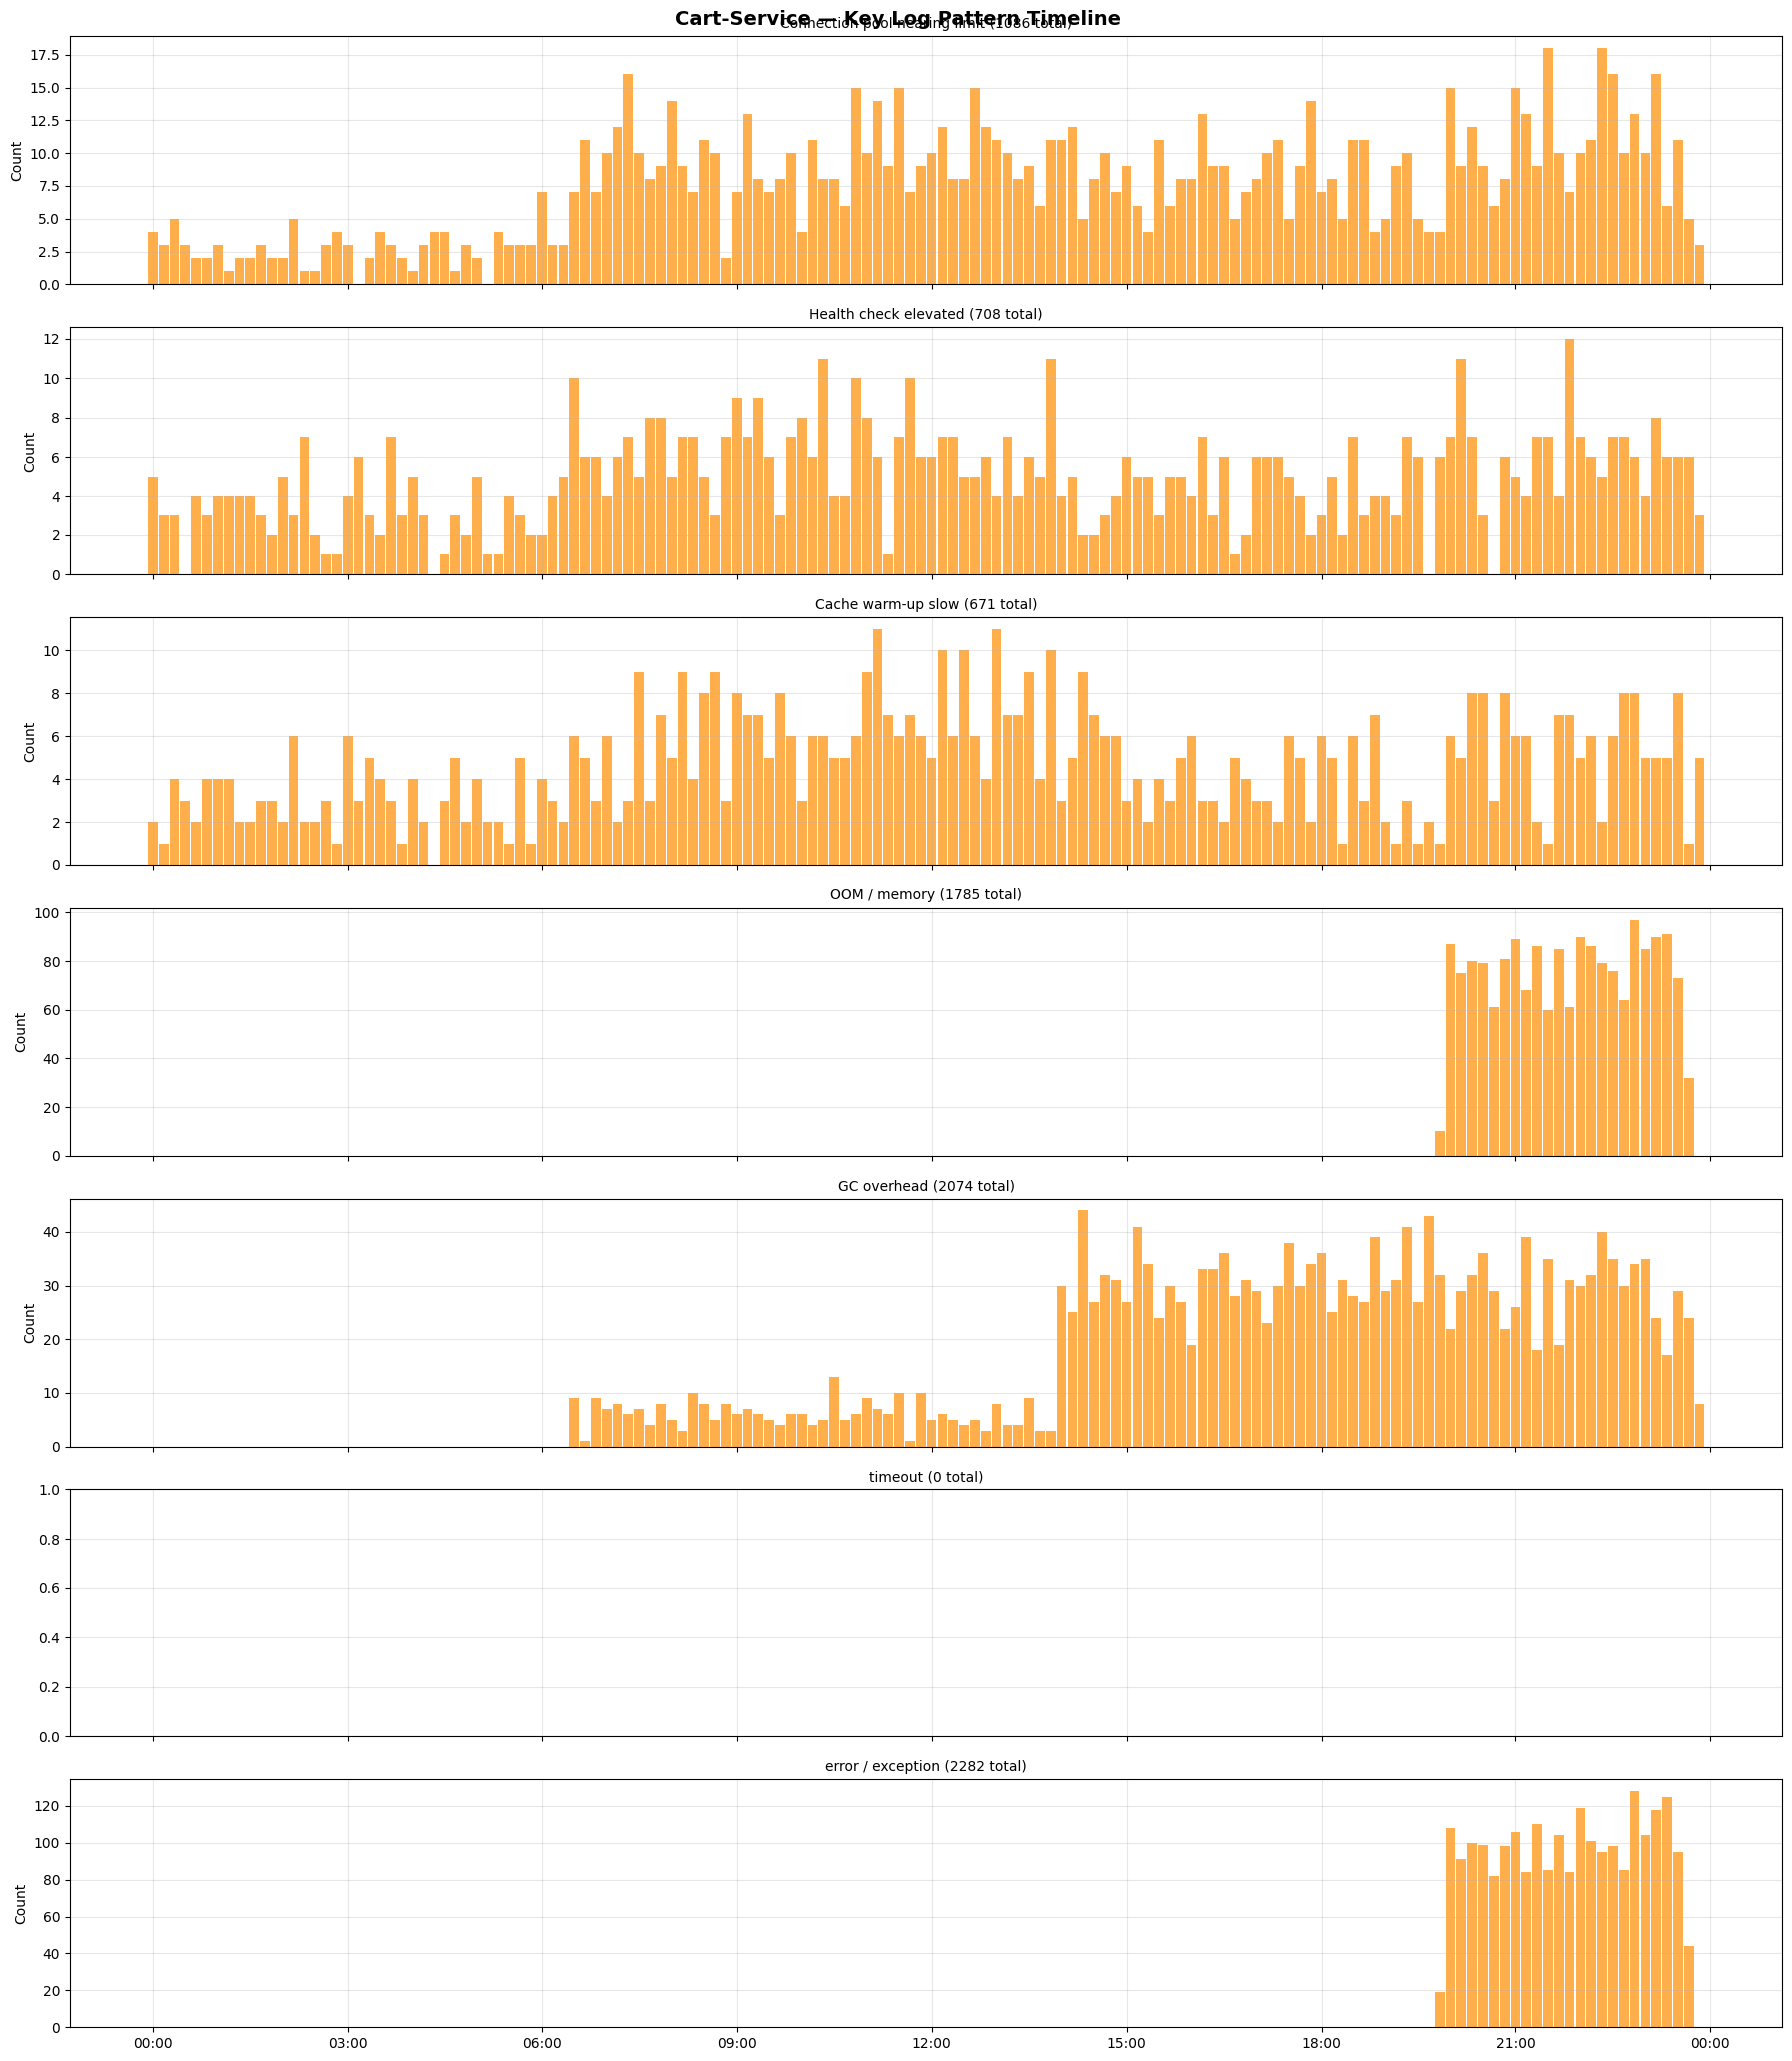

In [5]:
# Track key log patterns over time
patterns = {
    'Connection pool nearing limit': cart_logs['message'].str.contains('Connection pool', na=False),
    'Health check elevated': cart_logs['message'].str.contains('Health check response time elevated', na=False),
    'Cache warm-up slow': cart_logs['message'].str.contains('Cache warm-up slower', na=False),
    'OOM / memory': cart_logs['message'].str.contains('OutOfMemory|memory|OOM', case=False, na=False),
    'GC overhead': cart_logs['message'].str.contains('GC overhead|garbage collect', case=False, na=False),
    'timeout': cart_logs['message'].str.contains('timeout|timed out', case=False, na=False),
    'error / exception': cart_logs[cart_logs['level'].isin(['ERROR', 'FATAL'])].index,
}

fig, axes = plt.subplots(len(patterns), 1, figsize=(18, 3 * len(patterns)), sharex=True)
fig.suptitle('Cart-Service — Key Log Pattern Timeline', fontsize=14, fontweight='bold')

for idx, (pattern_name, mask) in enumerate(patterns.items()):
    ax = axes[idx]
    if isinstance(mask, pd.Index):
        pattern_logs = cart_logs.loc[mask]
    else:
        pattern_logs = cart_logs[mask]

    if len(pattern_logs) > 0:
        counts = pattern_logs.set_index('timestamp').resample('10min').size()
        ax.bar(counts.index, counts.values, width=pd.Timedelta('9min'), alpha=0.7, color='darkorange')
        ax.set_ylabel('Count')
    ax.set_title(f'{pattern_name} ({len(pattern_logs)} total)', fontsize=10)
    ax.grid(True, alpha=0.3)

axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
plt.tight_layout()
plt.show()
